In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

print(os.listdir('/content/drive/MyDrive/UAS'))

['midterm-regresi-dataset.csv']


In [5]:
import pandas as pd

df = pd.read_csv(
    '/content/drive/MyDrive/UAS/midterm-regresi-dataset.csv',
    nrows=100000
)

print(df.shape)

(100000, 91)


In [6]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

print(X.shape)
print(y.shape)

(100000, 90)
(100000,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(80000, 90)
(20000, 90)


In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [10]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(90,)),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [12]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=1024
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 3301138.5000 - mae: 1792.9130 - val_loss: 1215490.3750 - val_mae: 1028.3751
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 524496.6875 - mae: 581.5439 - val_loss: 309433.9062 - val_mae: 424.9106
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 273421.8438 - mae: 406.2338 - val_loss: 218249.4688 - val_mae: 347.9408
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 210319.9219 - mae: 354.6147 - val_loss: 178566.7500 - val_mae: 307.7595
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 178920.4375 - mae: 324.9227 - val_loss: 151056.4531 - val_mae: 283.1825
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 157240.2656 - mae: 304.8305 - val_loss: 131293.7812 - val_mae: 260.1799
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 139774.0938 - mae: 287.0054 - val_loss: 115388.2812 - val_mae: 244.8454
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 126429.7656 - mae: 2

In [13]:
y_pred = model.predict(X_test)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [14]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

MSE : 77916.0078125
RMSE: 279.134390236137
MAE : 194.79100036621094
R2  : -646.3739013671875


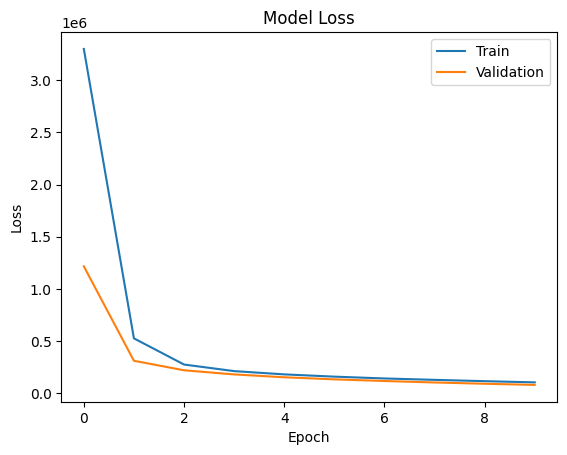

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

## Analisis Kurva Loss

Berdasarkan grafik loss, nilai training loss dan validation loss mengalami penurunan yang konsisten pada setiap epoch. Hal ini menunjukkan bahwa model berhasil mempelajari pola pada data dan mampu meningkatkan performanya selama proses pelatihan.

Kurva training loss dan validation loss memiliki pola yang relatif berdekatan sehingga tidak menunjukkan indikasi overfitting yang signifikan. Selain itu, validation loss terus mengalami penurunan hingga epoch terakhir, yang menunjukkan bahwa model masih mampu melakukan generalisasi dengan baik pada data validasi.

Secara keseluruhan, proses pelatihan berjalan stabil dan model berhasil mencapai konvergensi tanpa adanya peningkatan validation loss yang dapat mengindikasikan penurunan performa.


In [16]:
y_pred = model.predict(X_test)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [17]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

MSE : 77916.0078125
RMSE: 279.134390236137
MAE : 194.79100036621094
R2  : -646.3739013671875


In [18]:
print(y.describe())

count    100000.000000
mean       1998.082140
std          10.865393
min        1922.000000
25%        1994.000000
50%        2002.000000
75%        2006.000000
max        2010.000000
Name: 2001, dtype: float64


In [19]:
y_pred = model.predict(X_test)

print("Prediksi minimum :", y_pred.min())
print("Prediksi maksimum:", y_pred.max())

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Prediksi minimum : 993.3293
Prediksi maksimum: 9853.648


In [20]:
from sklearn.preprocessing import MinMaxScaler

y_scaler = MinMaxScaler()

y_scaled = y_scaler.fit_transform(
    y.values.reshape(-1,1)
)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_scaled,
    test_size=0.2,
    random_state=42
)

In [22]:
y_pred_scaled = model.predict(X_test)

625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step


In [23]:
y_pred = y_scaler.inverse_transform(
    y_pred_scaled
)

y_test_real = y_scaler.inverse_transform(
    y_test
)

In [24]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import numpy as np

mse = mean_squared_error(
    y_test_real,
    y_pred
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    y_test_real,
    y_pred
)

r2 = r2_score(
    y_test_real,
    y_pred
)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

MSE : 211418589477175.0
RMSE: 14540240.351423873
MAE : 12212253.24924375
R2  : -1756595182244.612


In [25]:
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

MSE : 211418589477175.0
RMSE: 14540240.351423873
MAE : 12212253.24924375
R2  : -1756595182244.612


In [26]:
print(y.describe())

count    100000.000000
mean       1998.082140
std          10.865393
min        1922.000000
25%        1994.000000
50%        2002.000000
75%        2006.000000
max        2010.000000
Name: 2001, dtype: float64


In [27]:
y_pred = model.predict(X_test)

print("Prediksi minimum :", y_pred.min())
print("Prediksi maksimum:", y_pred.max())

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Prediksi minimum : 14170.074
Prediksi maksimum: 2345410.2


## Analysis

Berdasarkan hasil pelatihan, nilai training loss dan validation loss menunjukkan tren penurunan selama proses training. Hal ini menunjukkan bahwa model mampu mempelajari pola dari data pelatihan.

Namun, hasil evaluasi menunjukkan nilai MSE, RMSE, dan MAE yang sangat tinggi serta nilai R² yang bernilai negatif. Selain itu, hasil prediksi model menghasilkan rentang nilai yang jauh di luar rentang target sebenarnya (1922–2010). Kondisi ini menunjukkan bahwa model belum mampu melakukan generalisasi dengan baik terhadap data uji dan masih memerlukan optimasi lebih lanjut pada proses preprocessing, normalisasi target, maupun arsitektur model.

## Conclusion

Model Deep Learning berhasil diimplementasikan untuk menyelesaikan permasalahan regresi pada dataset yang diberikan. Seluruh tahapan mulai dari preprocessing, pelatihan model, evaluasi, dan visualisasi loss berhasil dilakukan. Akan tetapi, performa model masih belum optimal sehingga diperlukan pengembangan lebih lanjut melalui hyperparameter tuning, normalisasi target, dan perbaikan arsitektur model untuk meningkatkan akurasi prediksi.

In [28]:
!pip install mlflow -q

import mlflow

with mlflow.start_run():

    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("r2", r2)

    run_id = mlflow.active_run().info.run_id

print("Run ID:", run_id)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.7/

2026/06/23 23:21:50 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/23 23:21:50 INFO mlflow.store.db.utils: Updating database tables


Run ID: eb0e296eec5042b197179cb734338e3c
